# Comparing Python Visualization Packages for Microbiome Data

This notebook compares three widely used Python visualization packages --
**Matplotlib**, **Seaborn**, and **Plotnine** -- by building the same
three chart types in each: a boxplot with statistical inference, a
stacked bar chart, and a longitudinal line plot with error bars. All
three are applied to one shared, reproducible mock microbiome dataset (a
Control arm and a Treatment arm sampled repeatedly over time), so the
outputs can be compared directly rather than across different data.

## Requirements

```
pip install numpy pandas scipy matplotlib seaborn plotnine
```

## Package philosophies, at a glance

| Package | Paradigm | Interactivity | Built-in statistics | Typical output |
|---|---|---|---|---|
| **Matplotlib** | Imperative, low-level | Static (interactive backends exist but are atypical in notebooks) | None -- you compute and place everything | Publication-ready static raster/vector |
| **Seaborn** | Declarative, statistical, built on Matplotlib | Static | Built-in aggregation, confidence intervals, regression fits | Publication-ready static raster/vector |
| **Plotnine** | Declarative, grammar-of-graphics (Python port of R's ggplot2) | Static | Statistical layers (`stat_*`) composable with geoms | Publication-ready static raster/vector |

## Suitability for microbiome data, briefly

- **Matplotlib** is the right choice when a chart needs a bespoke element
  no higher-level library provides -- e.g. the custom confidence ellipses
  and shape-coded group markers used for PCoA plots elsewhere in this
  project. Its cost is verbosity: every visual element must be placed
  explicitly.
- **Seaborn** is well suited to the standard, statistically-oriented
  comparisons that dominate microbiome analysis -- grouped boxplots,
  aggregated line plots with confidence bands -- with far less code than
  Matplotlib for the same result. Its main gap for compositional data is
  the lack of a dedicated stacked-bar function (Section 4 below shows the
  workaround).
- **Plotnine** is a good fit for anyone already thinking in ggplot2's
  grammar of graphics, and its layered `geom_*` system composes cleanly
  for faceted, multi-panel comparisons (e.g. one panel per group) with
  very little code. Its ecosystem is smaller than the other two, so
  less-common chart types may require more manual construction.

A note on scope: an interactive, web-based library (e.g. Plotly) is
often included in this kind of comparison, since interactivity is
genuinely valuable for exploring large ordinations or dense networks.
It's deliberately left out here, in favor of keeping this notebook
reliably reproducible across environments using only well-established,
static-output libraries.

Each of the three chart types below is followed by a short,
chart-specific version of this same discussion.

## Setup

Core packages (NumPy, pandas, SciPy, Matplotlib, Seaborn) are imported
directly. Plotnine is imported defensively -- if it is missing, the
corresponding cells later in the notebook will raise a clear,
informative error rather than an obscure one, and the final comparison
grid will substitute a placeholder for any missing chart rather than
failing outright.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
from scipy.stats import mannwhitneyu
from IPython.display import display

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

CHART_DIR = "charts"
os.makedirs(CHART_DIR, exist_ok=True)

# Imported defensively: importing catches ANY exception (not just
# ImportError), since a package can be installed yet still fail on
# import due to an internal incompatibility -- printing a clear
# diagnostic and letting the rest of the notebook continue, rather than
# the whole Setup cell crashing.
try:
    from plotnine import (ggplot, aes, geom_boxplot, geom_jitter, geom_col, geom_line,
                           geom_point, geom_errorbar, facet_wrap, labs, theme_minimal,
                           annotate, element_text, theme, scale_color_manual, scale_fill_manual)
    PLOTNINE_AVAILABLE = True
except Exception as e:
    PLOTNINE_AVAILABLE = False
    print(f"Plotnine unavailable ({type(e).__name__}: {e}) -- "
          "install with `pip install plotnine` to run those cells.")

## Mock microbiome dataset

A longitudinal Control-vs-Treatment dataset, generated once and reused
for every chart in this notebook: ten taxa (`A`-`J`), a Control arm whose
composition only fluctuates with noise, and a Treatment arm in which five
taxa decline while five proportionally expand over eight weeks.

In [6]:
def generate_mock_community(
    n_taxa=10, n_weeks=8, n_replicates=20,
    min_abundance=0.03, max_abundance=0.40,
    control_noise=0.05, treatment_noise=0.35,
    decline_floor=0.2, random_seed=RANDOM_SEED,
):
    '''Simulate a longitudinal Control-vs-Treatment microbiome dataset:
    Control fluctuates only by noise; Treatment has 5 taxa decline and
    5 taxa proportionally expand over time. Returns a tidy long-format
    DataFrame (Sample, SubjectID, Group, Week, Replicate, Taxon, Abundance).'''
    taxa = [chr(ord("A") + i) for i in range(n_taxa)]
    rng_master = np.random.default_rng(random_seed)

    config = {
        "Control":   {"seed": int(rng_master.integers(0, 1_000_000)), "declining": [], "increasing": []},
        "Treatment": {"seed": int(rng_master.integers(0, 1_000_000)), "declining": taxa[:5], "increasing": taxa[5:]},
    }

    def baseline(seed):
        rng = np.random.default_rng(seed)
        b = rng.uniform(min_abundance, max_abundance, n_taxa)
        b = b / b.sum()
        b = np.clip(b, min_abundance, max_abundance)
        return b / b.sum()

    def profile(base, week_idx, declining, increasing):
        if not declining:
            return base.copy()
        frac = np.linspace(1.0, decline_floor, n_weeks)[week_idx]
        p = pd.Series(base, index=taxa).copy()
        dec_total, inc_total = p[declining].sum(), p[increasing].sum()
        p[declining] = p[declining] * frac
        freed = dec_total * (1 - frac)
        p[increasing] = p[increasing] + freed * (p[increasing] / inc_total)
        return (p / p.sum()).values

    records = []
    for group, cfg in config.items():
        base = baseline(cfg["seed"])
        rng = np.random.default_rng(cfg["seed"] + 1)
        noise = control_noise if group == "Control" else treatment_noise
        for week in range(1, n_weeks + 1):
            expected = profile(base, week - 1, cfg["declining"], cfg["increasing"])
            for rep in range(1, n_replicates + 1):
                pert = rng.uniform(-noise, noise, n_taxa)
                obs = expected * (1 + pert)
                obs = np.clip(obs, min_abundance * 0.1, max_abundance)
                obs = obs / obs.sum()
                for taxon, val in zip(taxa, obs):
                    records.append({
                        "Sample": f"{group}_{week}_{rep}", "SubjectID": f"{group}_{rep}",
                        "Group": group, "Week": week, "Replicate": rep,
                        "Taxon": taxon, "Abundance": round(float(val), 5),
                    })

    df = pd.DataFrame.from_records(records)
    df["Group"] = pd.Categorical(df["Group"], categories=["Control", "Treatment"], ordered=True)
    return df


df = generate_mock_community()
print(f"Shape: {df.shape}")
print(f"Groups: {df['Group'].cat.categories.tolist()}")
df.head()

Shape: (3200, 7)
Groups: ['Control', 'Treatment']


,Sample,SubjectID,Group,Week,Replicate,Taxon,Abundance
0,Control_1_1,Control_1,Control,1,1,A,0.08882
1,Control_1_1,Control_1,Control,1,1,B,0.04120
2,Control_1_1,Control_1,Control,1,1,C,0.14081
3,Control_1_1,Control_1,Control,1,1,D,0.07581
4,Control_1_1,Control_1,Control,1,1,E,0.19737


In [7]:
# Shared setup used by every chart below
snapshot = df[df["Week"] == df["Week"].max()]          # cross-sectional slice for the boxplot
mean_abund = df.groupby(["Group", "Week", "Taxon"])["Abundance"].mean().reset_index()  # for the stacked bar
taxa_order = mean_abund.groupby("Taxon")["Abundance"].mean().sort_values(ascending=False).index.tolist()

FOCUS_TAXON = "A"   # single taxon used for the boxplot and line-plot sections, for a focused comparison
taxon_df = snapshot[snapshot["Taxon"] == FOCUS_TAXON]
taxon_over_time = df[df["Taxon"] == FOCUS_TAXON]

control_vals = taxon_df.loc[taxon_df["Group"] == "Control", "Abundance"].values
treatment_vals = taxon_df.loc[taxon_df["Group"] == "Treatment", "Abundance"].values
_, P_VALUE = mannwhitneyu(control_vals, treatment_vals, alternative="two-sided")
STARS = "***" if P_VALUE < 0.001 else "**" if P_VALUE < 0.01 else "*" if P_VALUE < 0.05 else "ns"

print(f"Taxon {FOCUS_TAXON} at Week {df['Week'].max()}: Mann-Whitney U p={P_VALUE:.4g} ({STARS})")

Taxon A at Week 8: Mann-Whitney U p=6.786e-08 (***)


## 3. Boxplot with statistical inference

**Which package is best suited here?** Both packages handle a basic
grouped boxplot easily; the differentiator is how much code is needed to
add the significance bracket and p-value annotation seen in most
published microbiome figures. Seaborn's boxplot call itself is the most
concise, but neither library annotates significance automatically --
both versions below manually place the same bracket and label, computed
once from a single shared Mann-Whitney U test (Section 2) so the
comparison is fair. Plotnine's layered grammar makes the annotation code
read differently (composed as additional `+ annotate(...)` layers) but
is not meaningfully shorter.

### 3.1 Matplotlib

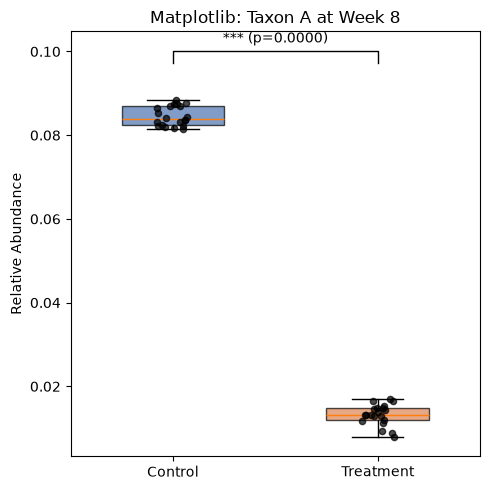

In [8]:
fig, ax = plt.subplots(figsize=(5, 5))

bp = ax.boxplot([control_vals, treatment_vals], tick_labels=["Control", "Treatment"],
                 patch_artist=True, widths=0.5)
for patch, color in zip(bp["boxes"], ["#4C72B0", "#DD8452"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

rng = np.random.default_rng(0)
for i, vals in enumerate([control_vals, treatment_vals], start=1):
    jitter = rng.uniform(-0.08, 0.08, len(vals))
    ax.scatter(np.full(len(vals), i) + jitter, vals, color="black", s=20, zorder=3, alpha=0.7)

y_top = max(control_vals.max(), treatment_vals.max()) * 1.1
ax.plot([1, 1, 2, 2], [y_top, y_top * 1.03, y_top * 1.03, y_top], color="black", lw=1)
ax.text(1.5, y_top * 1.05, f"{STARS} (p={P_VALUE:.4f})", ha="center", fontsize=10)

ax.set_ylabel("Relative Abundance")
ax.set_title(f"Matplotlib: Taxon {FOCUS_TAXON} at Week {df['Week'].max()}")
fig.tight_layout()
fig.savefig(f"{CHART_DIR}/matplotlib_boxplot.png", dpi=100, bbox_inches="tight")
plt.show()

### 3.2 Seaborn

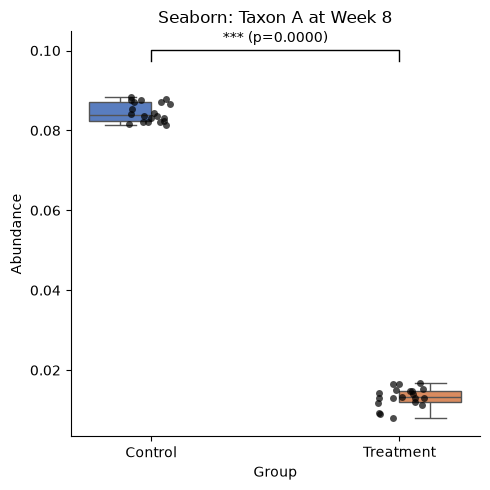

In [23]:
fig, ax = plt.subplots(figsize=(5, 5))

sns.boxplot(data=taxon_df, x="Group", y="Abundance", hue="Group", palette="muted",
            width=0.5, legend=False, ax=ax)
sns.stripplot(data=taxon_df, x="Group", y="Abundance", color="black", size=5,
              alpha=0.7, jitter=True, ax=ax)

y_top = taxon_df["Abundance"].max() * 1.1
ax.plot([0, 0, 1, 1], [y_top, y_top * 1.03, y_top * 1.03, y_top], color="black", lw=1)
ax.text(0.5, y_top * 1.05, f"{STARS} (p={P_VALUE:.4f})", ha="center", fontsize=10)

ax.set_title(f"Seaborn: Taxon {FOCUS_TAXON} at Week {df['Week'].max()}")
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(f"{CHART_DIR}/seaborn_boxplot.png", dpi=100, bbox_inches="tight")
plt.show()

### 3.3 Plotnine

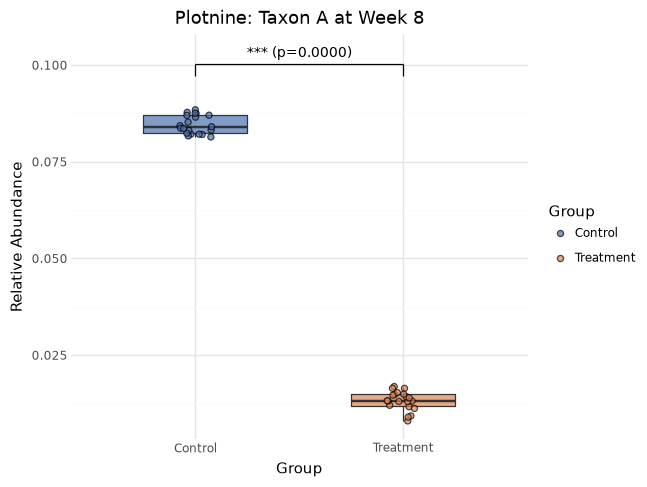

In [10]:
if PLOTNINE_AVAILABLE:
    y_top = taxon_df["Abundance"].max() * 1.1

    p_box = (
        ggplot(taxon_df, aes(x="Group", y="Abundance", fill="Group"))
        + geom_boxplot(width=0.5, alpha=0.7, show_legend=False)
        + geom_jitter(width=0.08, size=2, color="black", alpha=0.7)
        + scale_fill_manual(values={"Control": "#4C72B0", "Treatment": "#DD8452"})
        + annotate("segment", x=1, xend=1, y=y_top, yend=y_top * 1.03)
        + annotate("segment", x=1, xend=2, y=y_top * 1.03, yend=y_top * 1.03)
        + annotate("segment", x=2, xend=2, y=y_top, yend=y_top * 1.03)
        + annotate("text", x=1.5, y=y_top * 1.06, label=f"{STARS} (p={P_VALUE:.4f})", size=10)
        + labs(title=f"Plotnine: Taxon {FOCUS_TAXON} at Week {df['Week'].max()}", y="Relative Abundance")
        + theme_minimal()
    )
    p_box.save(f"{CHART_DIR}/plotnine_boxplot.png", width=5, height=5, dpi=100, verbose=False)
    # draw() alone won't auto-render here since it's nested inside this
    # if-block -- Jupyter's auto-display only catches a cell's bare,
    # top-level last expression, not one nested inside a compound
    # statement. display() renders it explicitly and reliably.
    display(p_box.draw())
else:
    print("Skipping: Plotnine is not installed.")

## 4. Stacked bar chart

**Which package is best suited here?** Plotnine (`geom_col(position="stack")`)
provides stacking as a first-class, one-line declaration that composes
trivially with per-group faceting. Matplotlib requires manually tracking
and passing a running `bottom` array. Seaborn has **no dedicated
stacked-bar function at all** -- the Seaborn version below is really a
Matplotlib stacked bar drawn using Seaborn's color palette and theme,
which is the standard workaround in practice.

### 4.1 Matplotlib

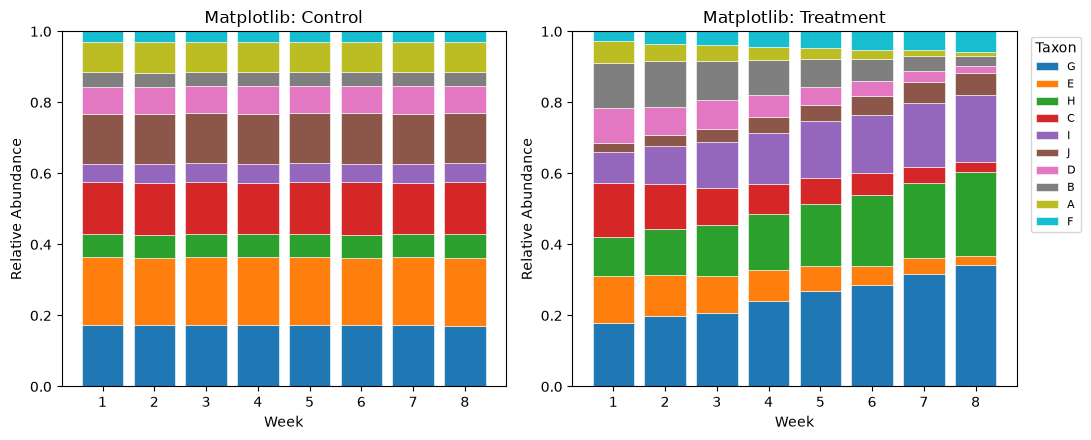

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
palette = sns.color_palette("tab10", len(taxa_order))

for ax, group in zip(axes, ["Control", "Treatment"]):
    sub = mean_abund[mean_abund["Group"] == group].pivot(index="Week", columns="Taxon", values="Abundance")[taxa_order]
    bottom = np.zeros(len(sub))
    for taxon, color in zip(taxa_order, palette):
        ax.bar(sub.index.astype(str), sub[taxon], bottom=bottom, color=color,
               label=taxon, edgecolor="white", linewidth=0.4)
        bottom += sub[taxon].values
    ax.set_title(f"Matplotlib: {group}")
    ax.set_ylim(0, 1)
    ax.set_xlabel("Week")
    ax.set_ylabel("Relative Abundance")

axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Taxon", fontsize=8)
fig.tight_layout()
fig.savefig(f"{CHART_DIR}/matplotlib_stacked.png", dpi=100, bbox_inches="tight")
plt.show()

### 4.2 Seaborn

Seaborn's own API has no `stack` option for bar charts; this cell uses
Seaborn only for its color palette and plot theme, with the actual
stacking mechanics handled by Matplotlib underneath -- illustrating the
workaround described above.

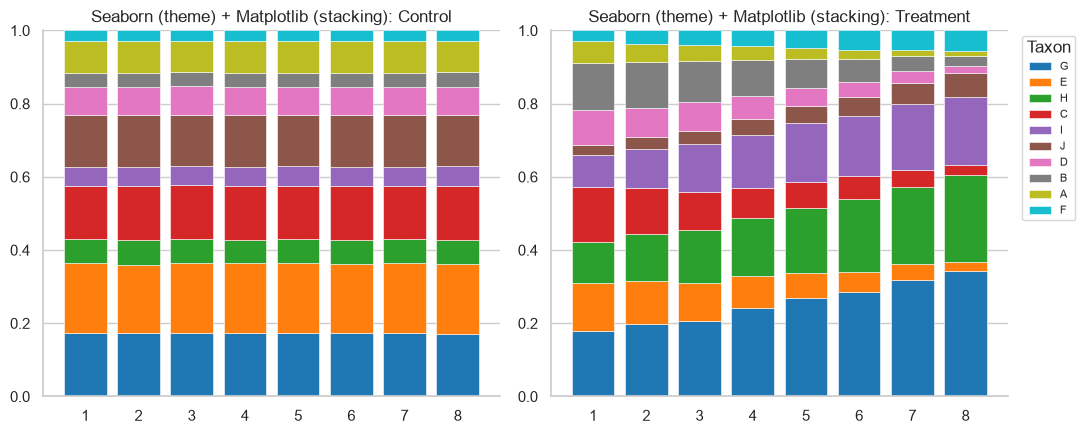

In [12]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
palette = sns.color_palette("tab10", len(taxa_order))

for ax, group in zip(axes, ["Control", "Treatment"]):
    sub = mean_abund[mean_abund["Group"] == group].pivot(index="Week", columns="Taxon", values="Abundance")[taxa_order]
    bottom = np.zeros(len(sub))
    for taxon, color in zip(taxa_order, palette):
        ax.bar(sub.index.astype(str), sub[taxon], bottom=bottom, color=color,
               label=taxon, edgecolor="white", linewidth=0.4)
        bottom += sub[taxon].values
    ax.set_title(f"Seaborn (theme) + Matplotlib (stacking): {group}")
    ax.set_ylim(0, 1)
    sns.despine(ax=ax)

axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", title="Taxon", fontsize=8)
fig.tight_layout()
fig.savefig(f"{CHART_DIR}/seaborn_stacked.png", dpi=100, bbox_inches="tight")
plt.show()
sns.reset_defaults()

### 4.3 Plotnine

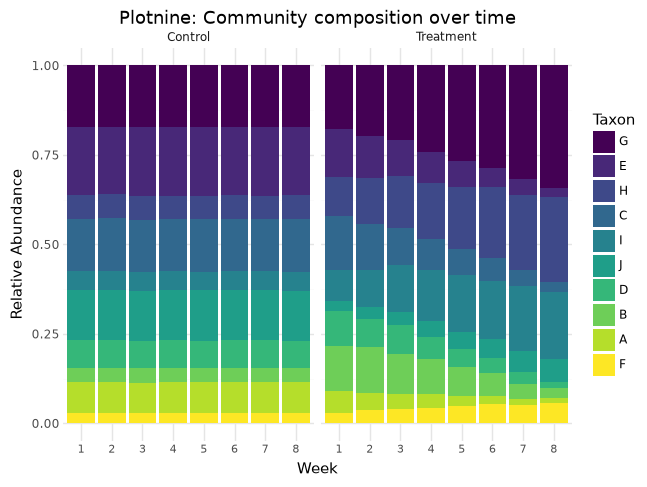

In [13]:
if PLOTNINE_AVAILABLE:
    mean_abund_ordered = mean_abund.copy()
    mean_abund_ordered["Taxon"] = pd.Categorical(mean_abund_ordered["Taxon"], categories=taxa_order, ordered=True)

    p_bar = (
        ggplot(mean_abund_ordered, aes(x="factor(Week)", y="Abundance", fill="Taxon"))
        + geom_col(position="stack")
        + facet_wrap("~Group")
        + labs(title="Plotnine: Community composition over time", x="Week", y="Relative Abundance")
        + theme_minimal()
        + theme(axis_text_x=element_text(size=8))
    )
    p_bar.save(f"{CHART_DIR}/plotnine_stacked.png", width=11, height=4.5, dpi=100, verbose=False)
    display(p_bar.draw())
else:
    print("Skipping: Plotnine is not installed.")

## 5. Longitudinal line plot with error bars

**Which package is best suited here?** Seaborn is the most concise for
this specific chart: `sns.lineplot(..., errorbar="sd")` computes the
mean and error band directly from raw, unaggregated data in one call.
Matplotlib and Plotnine both require the mean/SD to be aggregated by
hand first (via `groupby`) before plotting.

### 5.1 Matplotlib

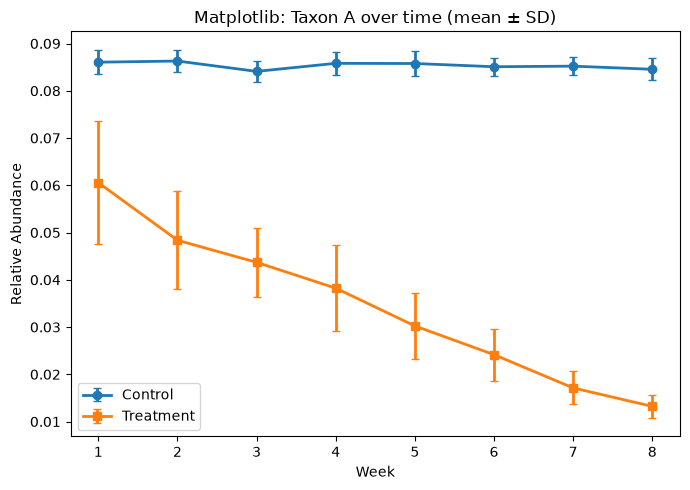

In [14]:
fig, ax = plt.subplots(figsize=(7, 5))

for group, marker in zip(["Control", "Treatment"], ["o", "s"]):
    sub = taxon_over_time[taxon_over_time["Group"] == group].groupby("Week")["Abundance"].agg(["mean", "std"]).reset_index()
    ax.errorbar(sub["Week"], sub["mean"], yerr=sub["std"], marker=marker, capsize=3, label=group, linewidth=2)

ax.set_xlabel("Week")
ax.set_ylabel("Relative Abundance")
ax.set_title(f"Matplotlib: Taxon {FOCUS_TAXON} over time (mean \u00b1 SD)")
ax.legend()
fig.tight_layout()
fig.savefig(f"{CHART_DIR}/matplotlib_line.png", dpi=100, bbox_inches="tight")
plt.show()

### 5.2 Seaborn

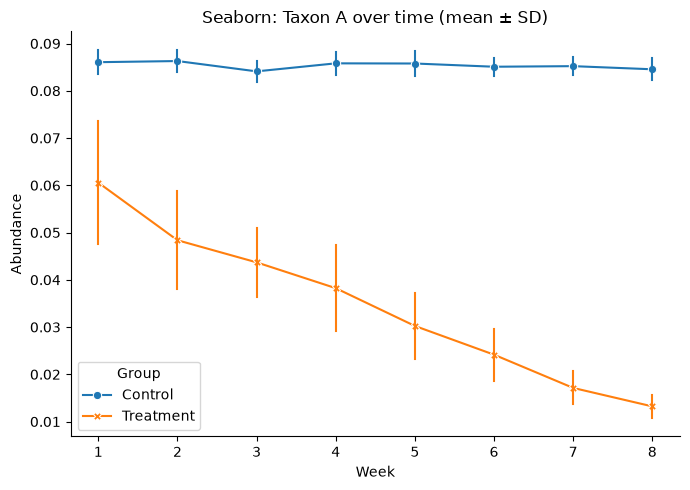

In [15]:
fig, ax = plt.subplots(figsize=(7, 5))

sns.lineplot(data=taxon_over_time, x="Week", y="Abundance", hue="Group", style="Group",
             markers=True, dashes=False, errorbar="sd", err_style="bars", ax=ax)

ax.set_title(f"Seaborn: Taxon {FOCUS_TAXON} over time (mean \u00b1 SD)")
sns.despine(ax=ax)
fig.tight_layout()
fig.savefig(f"{CHART_DIR}/seaborn_line.png", dpi=100, bbox_inches="tight")
plt.show()

### 5.3 Plotnine

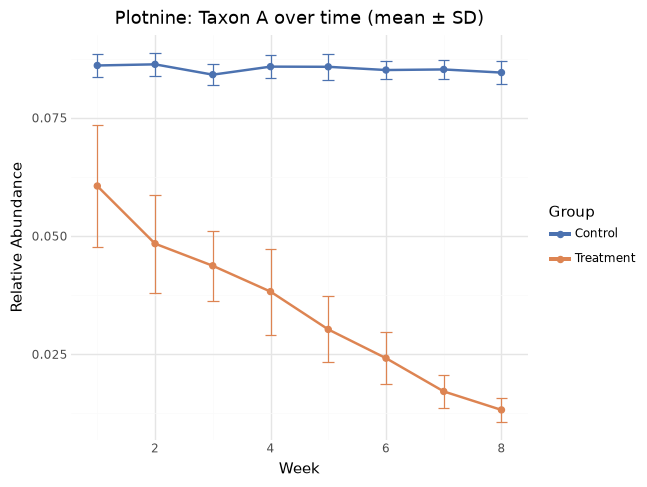

In [16]:
if PLOTNINE_AVAILABLE:
    summary = taxon_over_time.groupby(["Group", "Week"])["Abundance"].agg(["mean", "std"]).reset_index()
    summary["ymin"] = summary["mean"] - summary["std"]
    summary["ymax"] = summary["mean"] + summary["std"]

    p_line = (
        ggplot(summary, aes(x="Week", y="mean", color="Group"))
        + geom_line(size=1)
        + geom_point(size=2)
        + geom_errorbar(aes(ymin="ymin", ymax="ymax"), width=0.2)
        + scale_color_manual(values={"Control": "#4C72B0", "Treatment": "#DD8452"})
        + labs(title=f"Plotnine: Taxon {FOCUS_TAXON} over time (mean \u00b1 SD)", y="Relative Abundance", x="Week")
        + theme_minimal()
    )
    p_line.save(f"{CHART_DIR}/plotnine_line.png", width=7, height=5, dpi=100, verbose=False)
    display(p_line.draw())
else:
    print("Skipping: Plotnine is not installed.")

## 6. Side-by-side comparison

Every chart above saved a copy to the `charts/` folder as it was
generated. The cell below loads whichever of those images exist and
arranges them into one grid per chart type -- three columns (Matplotlib,
Seaborn, Plotnine), one row per chart type. If Plotnine was not
installed when the earlier cells ran, that column is shown as a labeled
placeholder instead of causing the whole grid to fail.

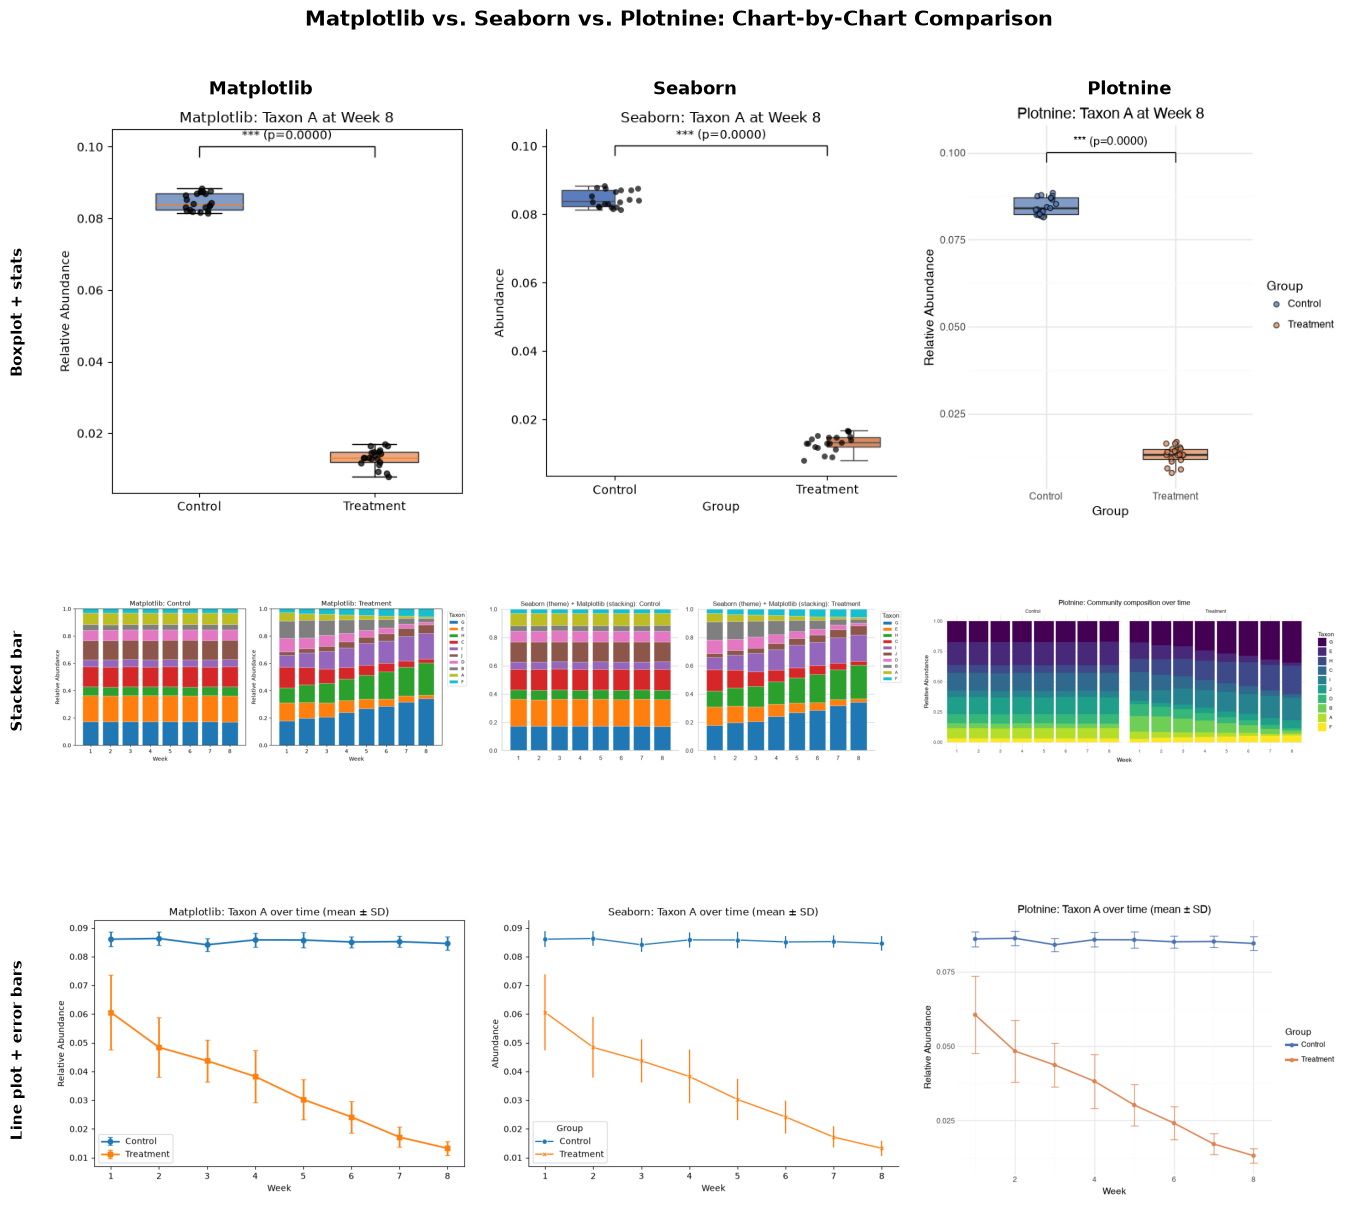

In [17]:
CHART_TYPES = ["boxplot", "stacked", "line"]
CHART_TYPE_LABELS = {"boxplot": "Boxplot + stats", "stacked": "Stacked bar", "line": "Line plot + error bars"}
PACKAGES = ["matplotlib", "seaborn", "plotnine"]

fig, axes = plt.subplots(len(CHART_TYPES), len(PACKAGES),
                          figsize=(4.5 * len(PACKAGES), 4.2 * len(CHART_TYPES)))

for row, chart_type in enumerate(CHART_TYPES):
    for col, package in enumerate(PACKAGES):
        ax = axes[row, col]
        path = f"{CHART_DIR}/{package}_{chart_type}.png"
        if os.path.exists(path):
            ax.imshow(mpimg.imread(path))
        else:
            ax.text(0.5, 0.5, f"{package}\n(not available)", ha="center", va="center",
                    fontsize=10, color="gray", transform=ax.transAxes)
        ax.axis("off")
        if row == 0:
            ax.set_title(package.capitalize(), fontsize=13, fontweight="bold")
        if col == 0:
            ax.text(-0.08, 0.5, CHART_TYPE_LABELS[chart_type], rotation=90, va="center", ha="center",
                    fontsize=11, fontweight="bold", transform=ax.transAxes)

fig.suptitle("Matplotlib vs. Seaborn vs. Plotnine: Chart-by-Chart Comparison",
             fontsize=15, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(f"{CHART_DIR}/_full_comparison_grid.png", dpi=100, bbox_inches="tight")
plt.show()

## Summary

| Package | Boxplot + stats | Stacked bar | Line plot + error bars | Best overall fit for microbiome work |
|---|---|---|---|---|
| **Matplotlib** | Full manual control; most verbose | Manual `bottom` tracking | Manual aggregation + `errorbar()` | Bespoke figures needing exact control (e.g. custom ordination plots) |
| **Seaborn** | Most concise boxplot call | No native support -- falls back to Matplotlib | Most concise overall (`errorbar="sd"` built in) | Everyday statistical comparisons across groups |
| **Plotnine** | Layered `geom_boxplot` + `geom_jitter`; manual annotation | Native `position="stack"` + `facet_wrap` | Manual aggregation + `geom_errorbar` | Faceted, publication-style multi-panel figures, ggplot2 users |

No single package dominates every chart type. Of the three compared
here, **Seaborn** required the least code for the boxplot and line plot,
**Plotnine** was cleanest for the stacked bar (Seaborn's biggest gap),
and **Matplotlib** remained the common foundation underneath both
Seaborn and the Seaborn-styled stacked-bar workaround -- consistent with
its role throughout this project as the tool of choice when a chart
needs an element no higher-level library provides out of the box.